## What are the most demand skills for the top 3 data roles?

In [32]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from ast import literal_eval

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:literal_eval(x) if pd.notna(x) else x)

In [33]:
df_US = df[df['job_country'] == 'United States'].copy()
df_US = df_US.explode('job_skills')
df_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,python,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,c++,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,java,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,matlab,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785692,Data Scientist,Data Scientist- Hybrid Work Location,"Dayton, OH",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-21 06:02:31,False,True,United States,year,157500.0,NaN,Tenet3,r,"{'programming': ['python', 'matlab', 'r']}"
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,None,NaN,NaN,Axelon Services Corporation,None,None
785705,Data Analyst,Expert Business Data Analyst - Now Hiring,"Oakland, CA",via Snagajob,Full-time,False,"California, United States",2023-01-09 06:00:25,False,False,United States,None,NaN,NaN,PG&E Corporation,sql,"{'analyst_tools': ['tableau'], 'programming': ..."
785705,Data Analyst,Expert Business Data Analyst - Now Hiring,"Oakland, CA",via Snagajob,Full-time,False,"California, United States",2023-01-09 06:00:25,False,False,United States,None,NaN,NaN,PG&E Corporation,python,"{'analyst_tools': ['tableau'], 'programming': ..."


In [34]:
df_skill_count = df_US.groupby(['job_skills','job_title_short']).size()
df_skill_count = df_skill_count.reset_index(name='count').sort_values(by='count', ascending = False)
job_titles = df_skill_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
df_skill_count

,job_skills,job_title_short,count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


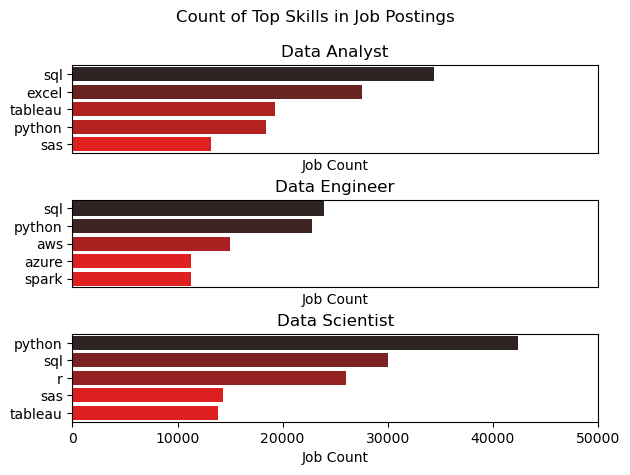

In [82]:
fig,ax = plt.subplots(len(job_titles),1)
for i,titles in enumerate(job_titles):
    df_plot = df_skill_count[df_skill_count['job_title_short'] == titles].head(5)
    #df_plot.plot(kind='barh',y='count',x='job_skills', ax=ax[i],legend=False)
    sns.barplot(data=df_plot,x='count',y='job_skills', ax=ax[i],legend=False, hue='count',palette='dark:r_r')
    ax[i].set_xlabel('Job Count')
    ax[i].set_ylabel('')
    ax[i].set_title(titles)
    ax[i].set_xlim(0,50000)
    if i!= len(job_titles)-1:
        ax[i].set_xticks([])
fig.suptitle('Count of Top Skills in Job Postings')
fig.tight_layout(h_pad=.5)

In [85]:
df_total_job = df_US['job_title_short'].value_counts().reset_index(name='job_total')

In [86]:
df_skills_perc = pd.merge(df_skill_count, df_total_job, how='left', on='job_title_short')
df_skills_perc

,job_skills,job_title_short,count,job_total
0,python,Data Scientist,42379,322290
1,sql,Data Analyst,34452,254289
2,sql,Data Scientist,30034,322290
3,excel,Data Analyst,27519,254289
4,r,Data Scientist,26022,322290
...,...,...,...,...
1865,vue.js,Business Analyst,1,26518
1866,arch,Business Analyst,1,26518
1867,asana,Machine Learning Engineer,1,5517
1868,no-sql,Machine Learning Engineer,1,5517


In [ ]:
df_skills_perc['percent'] = 100 * df_skills_perc['count']/df_skills_perc['job_total']
df_skills_perc

,job_skills,job_title_short,count,job_total,percent
0,python,Data Scientist,42379,322290,13.149338
1,sql,Data Analyst,34452,254289,13.548364
2,sql,Data Scientist,30034,322290,9.318936
3,excel,Data Analyst,27519,254289,10.821939
4,r,Data Scientist,26022,322290,8.074095
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,26518,0.003771
1866,arch,Business Analyst,1,26518,0.003771
1867,asana,Machine Learning Engineer,1,5517,0.018126
1868,no-sql,Machine Learning Engineer,1,5517,0.018126


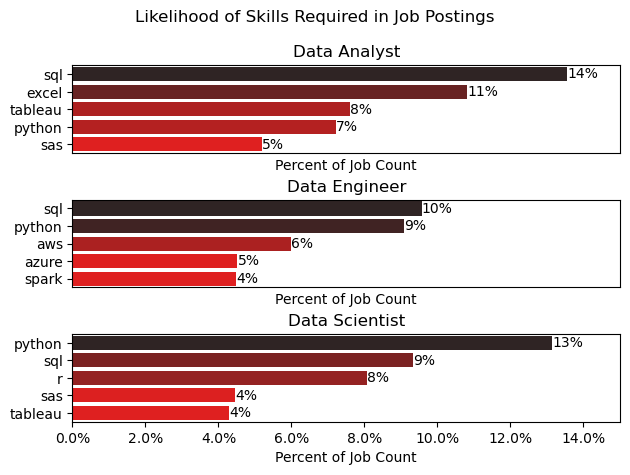

In [80]:
fig,ax = plt.subplots(len(job_titles),1)
for i,titles in enumerate(job_titles):
    df_plot_percent = df_skills_perc[df_skills_perc['job_title_short'] == titles].head(5)
    #df_plot.plot(kind='barh',y='count',x='job_skills', ax=ax[i],legend=False)
    sns.barplot(data=df_plot_percent,x='percent',y='job_skills', ax=ax[i],legend=False, hue='count',palette='dark:r_r')
    ax[i].set_xlabel('Percent of Job Count')
    ax[i].set_ylabel('')
    ax[i].set_title(titles)
    ax[i].set_xlim(0,15)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos: f'{x}%'))

    for n,v in enumerate(df_plot_percent['percent']):
        ax[i].text(v,n,f'{v:.0f}%',va='center')
    if i != (len(job_titles)-1):
        ax[i].set_xticks([])

fig.suptitle('Likelihood of Skills Required in Job Postings')
fig.tight_layout(h_pad=.5) #fix the overlap